##K-Means Clustering Algorithm with Scikit-Learn

In [2]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans


In [3]:
X,y_true=make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

In [4]:
#Scale the features so distance calculations are accurate
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

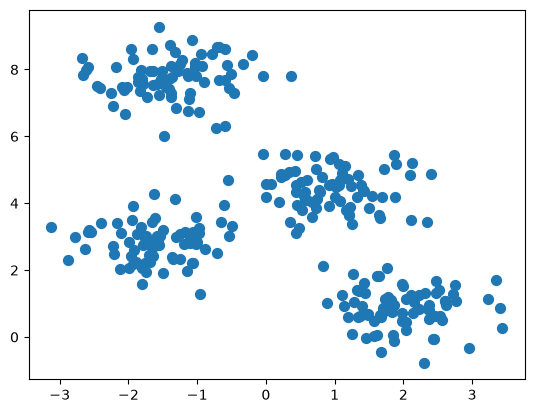

In [5]:
#Visualising the dataset before creating clusters
plt.scatter(X[:,0],X[:,1],s=50);

<function matplotlib.pyplot.show(close=None, block=None)>

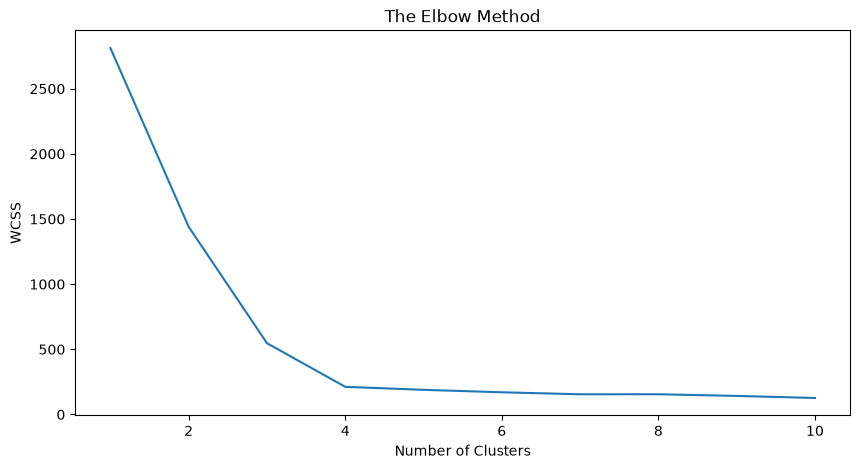

In [7]:
#Methods to find the optimal clusters in K-Means
#WCSS method and Ellbow Method can be used to find no. of optimal Clusters
from scipy.__config__ import show


wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show

In [ ]:
optimum_k = 4
kmeans = KMeans(n_clusters=optimum_k, init='k-means++', random_state=42)

In [9]:
cluster_labels=kmeans.fit_predict(X_scaled)
centroids=kmeans.cluster_centers_
print("Cluster Labels:", cluster_labels)
print("Centroids:", centroids)

Cluster Labels: [0 1 3 5 0 8 2 3 5 5 2 1 3 1 0 7 3 6 4 4 8 0 7 2 2 7 0 7 2 7 5 1 9 5 1 1 1
 1 2 0 3 2 7 9 2 4 1 4 1 6 2 6 5 0 0 4 5 4 1 0 1 7 1 4 2 4 1 6 1 4 3 4 5 4
 4 5 2 3 6 5 0 3 0 0 5 3 6 7 1 1 3 0 1 2 4 3 0 6 7 2 5 0 5 6 3 6 6 3 1 3 4
 4 0 1 0 9 1 0 0 7 4 0 4 0 0 6 0 4 0 2 5 2 2 6 1 4 2 1 3 5 1 4 3 4 9 2 1 7
 5 1 1 3 5 7 0 4 5 2 0 3 1 3 3 0 3 2 4 7 0 3 3 5 0 9 4 5 6 6 3 4 6 9 2 4 7
 3 3 3 6 1 7 4 3 7 2 4 2 9 2 1 3 4 6 2 3 1 4 5 3 5 3 2 7 9 1 4 4 6 8 7 1 6
 6 2 0 2 3 5 5 9 3 1 3 0 4 3 6 4 5 2 8 7 8 1 1 1 1 4 4 5 9 4 0 7 2 2 4 6 6
 1 3 7 2 0 5 4 9 5 7 6 0 2 2 9 8 6 0 9 5 1 8 6 9 6 6 8 1 4 5 3 6 0 5 1 5 6
 6 7 5 2]
Centroids: [[ 0.91713874 -1.17161111]
 [-1.11430586  1.43333033]
 [-1.26245472 -0.4823901 ]
 [ 0.60844516  0.12239405]
 [-0.70696628 -0.40114791]
 [-0.48388227  1.49832993]
 [ 1.39399048 -1.23426016]
 [ 0.19668604  0.27192056]
 [ 1.88753797 -1.16799906]
 [ 1.16127352  0.15455136]]


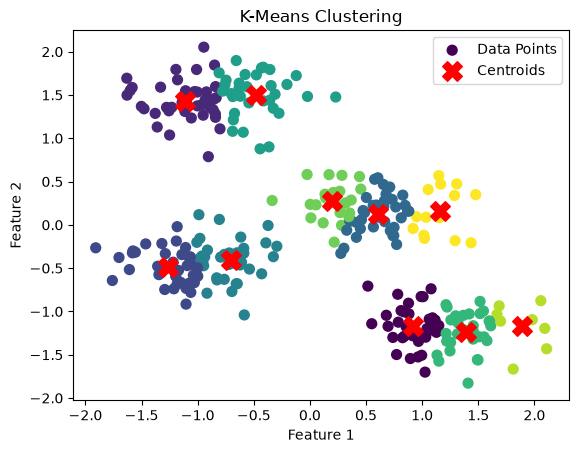

In [11]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], s=50, c=cluster_labels, cmap='viridis');
plt.scatter(centroids[:,0],centroids[:,1],c='red',s=200, marker='X');
plt.title('K-Means Clustering');
plt.xlabel('Feature 1');
plt.ylabel('Feature 2');
plt.legend(['Data Points', 'Centroids']);
plt.show();

In [21]:
#Second Method to check the optimum no. of cluster is Silhoutte Score
#Maximum Value of Silhoutte Score gives the optimum no. of clusters

from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range = range(2, 11)  # Silhouette score is not defined for k=1
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores)
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

TypeError: 'KMeans' object is not callable